# Ariketa 3.1: Ikasleen Noten eta Ikasketa Orduen Analisia (Datu Ofizialak)

**Iturria:** Moodle-ko mock datuak karpeta (Ariketa 3.1/ikasleak_notak_100.csv).
**Helburua:** Klase bateko 100 ikasleren notak eta ikasketa-orduak aztertzea Matplotlib 2x2 azpigrafikoak eta estatistikak erabiliz.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Kargatu Moodle-ko datu ofizialak (; bereizlea eta , hamartarra)
df = pd.read_csv('data/ikasleak_notak_100.csv', sep=';', decimal=',')
print(f'Errenkada kopurua: {len(df)}')
df.head(10)


Errenkada kopurua: 100


,Ikaslea,Nota,Orduak
0,Egil 1,5.0,17
1,Gaizka 2,9.1,72
2,Julen 3,4.0,20
3,Eder 4,4.1,17
4,Asier 5,6.3,44
5,Andoni 6,7.0,44
6,Egil 7,7.3,42
7,Xabier 8,4.2,14
8,Beñat 9,7.9,50
9,Iker 10,6.6,37


In [2]:
print('Deskribapen estatistikoa:')
df.describe()


Deskribapen estatistikoa:


,Nota,Orduak
count,100.000000,100.000000
mean,6.223000,41.310000
std,1.788112,20.239323
min,2.900000,10.000000
25%,4.750000,22.750000
50%,6.300000,41.500000
75%,7.350000,60.250000
max,10.000000,74.000000


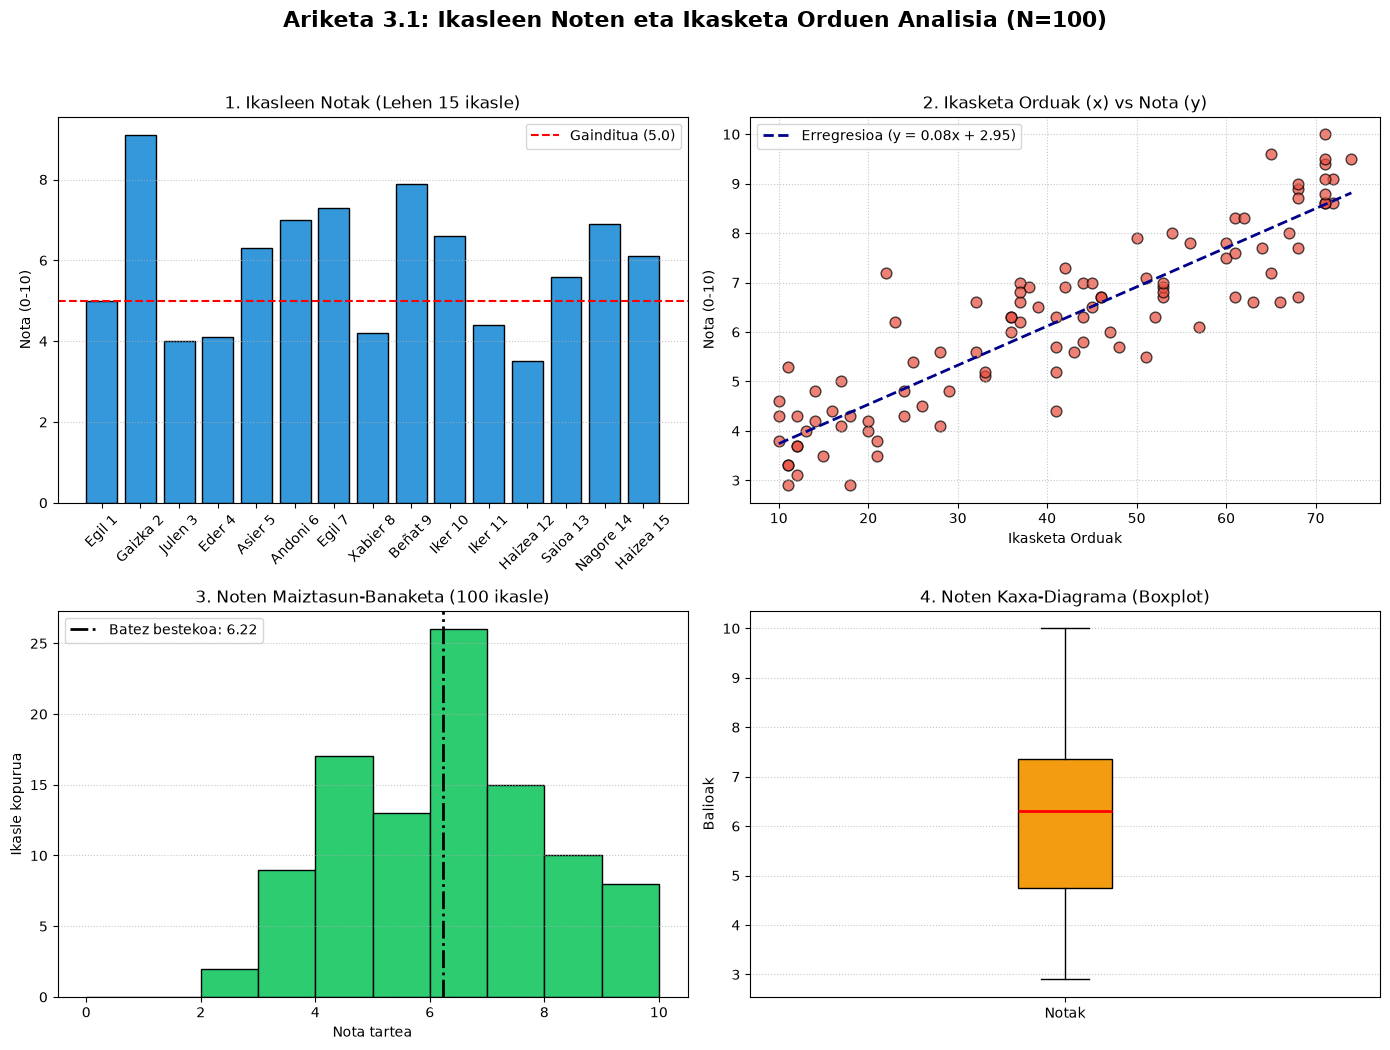

In [3]:
# 2. 2x2 Azpigrafikoak sortu eta bistaratu
fig, axs = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle('Ariketa 3.1: Ikasleen Noten eta Ikasketa Orduen Analisia (N=100)', fontsize=16, fontweight='bold')

# (0, 0) Barra-grafikoa (lehen 15 ikasle lagin adierazgarri moduan)
lagina = df.head(15)
axs[0, 0].bar(lagina['Ikaslea'], lagina['Nota'], color='#3498db', edgecolor='black')
axs[0, 0].axhline(5.0, color='red', linestyle='--', label='Gainditua (5.0)')
axs[0, 0].set_title('1. Ikasleen Notak (Lehen 15 ikasle)')
axs[0, 0].set_ylabel('Nota (0-10)')
axs[0, 0].tick_params(axis='x', rotation=45)
axs[0, 0].legend()
axs[0, 0].grid(axis='y', linestyle=':', alpha=0.7)

# (0, 1) Sakabanaketa eta Erregresio Zuzena
axs[0, 1].scatter(df['Orduak'], df['Nota'], color='#e74c3c', alpha=0.7, edgecolors='black', s=60)
m, b = np.polyfit(df['Orduak'], df['Nota'], 1)
x_vals = np.linspace(df['Orduak'].min(), df['Orduak'].max(), 100)
axs[0, 1].plot(x_vals, m * x_vals + b, color='darkblue', linestyle='--', linewidth=2, label=f'Erregresioa (y = {m:.2f}x + {b:.2f})')
axs[0, 1].set_title('2. Ikasketa Orduak (x) vs Nota (y)')
axs[0, 1].set_xlabel('Ikasketa Orduak')
axs[0, 1].set_ylabel('Nota (0-10)')
axs[0, 1].legend()
axs[0, 1].grid(True, linestyle=':', alpha=0.7)

# (1, 0) Histograma
axs[1, 0].hist(df['Nota'], bins=10, color='#2ecc71', edgecolor='black', range=(0, 10))
axs[1, 0].axvline(df['Nota'].mean(), color='black', linestyle='-.', linewidth=2, label=f'Batez bestekoa: {df["Nota"].mean():.2f}')
axs[1, 0].set_title('3. Noten Maiztasun-Banaketa (100 ikasle)')
axs[1, 0].set_xlabel('Nota tartea')
axs[1, 0].set_ylabel('Ikasle kopurua')
axs[1, 0].legend()
axs[1, 0].grid(axis='y', linestyle=':', alpha=0.7)

# (1, 1) Boxplot
axs[1, 1].boxplot(df['Nota'], patch_artist=True, tick_labels=['Notak'],
                 boxprops=dict(facecolor='#f39c12', color='black'),
                 medianprops=dict(color='red', linewidth=2))
axs[1, 1].set_title('4. Noten Kaxa-Diagrama (Boxplot)')
axs[1, 1].set_ylabel('Balioak')
axs[1, 1].grid(axis='y', linestyle=':', alpha=0.7)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('grafikoak/grafikoa_3_1_ofiziala.png', dpi=300)
plt.savefig('grafikoak/grafikoa_3_1_ofiziala.pdf')
plt.show()


In [4]:
# Korrelazioaren kalkulua eta ondorioak
r = np.corrcoef(df['Orduak'], df['Nota'])[0, 1]
print(f'Pearson korrelazio-koefizientea: r = {r:.3f}')
if r > 0.8:
    print('Ondorioa: Korrelazio lineal positibo oso altua dago ikasketa orduen eta lortutako noten artean.')


Pearson korrelazio-koefizientea: r = 0.897
Ondorioa: Korrelazio lineal positibo oso altua dago ikasketa orduen eta lortutako noten artean.
